# Feature Files EDA - Preprocessed .npy and .pkl Analysis

**Objective**: Analyze all preprocessed feature files to verify data quality, understand distributions, and check for issues.

This notebook examines:
- Feature file inventory and sizes
- Feature dimensions across train/val/test splits
- Data quality (NaN, Inf, outliers)
- Feature distributions and correlations
- Scaler/transformer properties
- Target variable distributions

**Date**: November 28, 2025

## 1. Setup and Configuration

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from typing import Dict, Any

# Academic publication style settings
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)
sns.set_palette("deep")

# Configure matplotlib for publication quality
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Paths
features_dir = Path('../ml/features')
output_dir = Path('../results/figures/feature_eda')
output_dir.mkdir(exist_ok=True, parents=True)

# Feature names
AUDIO_FEATURE_NAMES = [
    'acousticness', 'instrumentalness', 'liveness', 'speechiness',
    'loudness', 'tempo', 'duration_ms', 'year', 'mode',
    'key_sin', 'key_cos',
    'genre_Blues', 'genre_Classical', 'genre_Country', 'genre_Electronic',
    'genre_Folk', 'genre_Hip-Hop', 'genre_Jazz', 'genre_Pop', 'genre_R&B', 'genre_Rock'
]

TEXT_STAT_NAMES = [
    'word_count', 'unique_word_count', 'unique_ratio', 'avg_word_length', 'char_count'
]

SENTIMENT_NAMES = [
    'sentiment_polarity', 'sentiment_subjectivity'
]

print("✓ Libraries imported and paths configured")
print("✓ Academic publication style configured")
print(f"  Features directory: {features_dir.absolute()}")
print(f"  Output directory: {output_dir.absolute()}")
print(f"\n✓ Feature names defined:")
print(f"  Audio features: {len(AUDIO_FEATURE_NAMES)}")
print(f"  Text statistics: {len(TEXT_STAT_NAMES)}")
print(f"  Sentiment features: {len(SENTIMENT_NAMES)}")

✓ Libraries imported and paths configured
  Features directory: /home/esstee/documents/bitirme/notebooks/../ml/features
  Output directory: /home/esstee/documents/bitirme/notebooks/../results/figures/feature_eda

✓ Feature names defined:
  Audio features: 21
  Text statistics: 5
  Sentiment features: 2


## 2. Feature File Inventory

List all available .npy and .pkl files in the features directory.

In [ ]:
# List all feature files
npy_files = sorted(features_dir.glob("*.npy"))
pkl_files = sorted(features_dir.glob("*.pkl"))

print(f"NumPy arrays (.npy): {len(npy_files)}")
print("=" * 60)
for f in npy_files:
    size_mb = f.stat().st_size / (1024**2)
    print(f"  {f.name:<35} {size_mb:>7.2f} MB")

print(f"\nPickle files (.pkl): {len(pkl_files)}")
print("=" * 60)
for f in pkl_files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<35} {size_kb:>7.2f} KB")

NumPy arrays (.npy): 21
  X_test_audio.npy                      13.18 MB
  X_test_sentiment.npy                   1.26 MB
  X_test_text_stats.npy                  3.14 MB
  X_train_audio.npy                     61.91 MB
  X_train_sentiment.npy                  5.90 MB
  X_train_text_stats.npy                14.74 MB
  X_val_audio.npy                       13.17 MB
  X_val_sentiment.npy                    1.25 MB
  X_val_text_stats.npy                   3.14 MB
  y_test_danceability.npy                0.31 MB
  y_test_energy.npy                      0.31 MB
  y_test_popularity.npy                  0.31 MB
  y_test_valence.npy                     0.31 MB
  y_train_danceability.npy               1.47 MB
  y_train_energy.npy                     1.47 MB
  y_train_popularity.npy                 1.47 MB
  y_train_valence.npy                    1.47 MB
  y_val_danceability.npy                 0.31 MB
  y_val_energy.npy                       0.31 MB
  y_val_popularity.npy                   0.31

## 3. Load All Features

Load audio, text statistics, sentiment, embeddings, and target variables.

In [ ]:
features = {}

# Audio features
try:
    features['audio'] = {
        'train': np.load(features_dir / 'X_train_audio.npy'),
        'val': np.load(features_dir / 'X_val_audio.npy'),
        'test': np.load(features_dir / 'X_test_audio.npy'),
    }
    print(f"✓ Audio features: {features['audio']['train'].shape}")
except FileNotFoundError:
    print("✗ Audio features not found")

# Text statistics
try:
    features['text_stats'] = {
        'train': np.load(features_dir / 'X_train_text_stats.npy'),
        'val': np.load(features_dir / 'X_val_text_stats.npy'),
        'test': np.load(features_dir / 'X_test_text_stats.npy'),
    }
    print(f"✓ Text stats: {features['text_stats']['train'].shape}")
except FileNotFoundError:
    print("✗ Text statistics not found")

# Sentiment
try:
    features['sentiment'] = {
        'train': np.load(features_dir / 'X_train_sentiment.npy'),
        'val': np.load(features_dir / 'X_val_sentiment.npy'),
        'test': np.load(features_dir / 'X_test_sentiment.npy'),
    }
    print(f"✓ Sentiment: {features['sentiment']['train'].shape}")
except FileNotFoundError:
    print("✗ Sentiment features not found")

# Embeddings
try:
    features['embeddings'] = {
        'train': np.load(features_dir / 'X_train_embeddings.npy'),
        'val': np.load(features_dir / 'X_val_embeddings.npy'),
        'test': np.load(features_dir / 'X_test_embeddings.npy'),
    }
    print(f"✓ Embeddings: {features['embeddings']['train'].shape}")
except FileNotFoundError:
    print("✗ Embeddings not found (run: python run_preprocessing.py --steps embeddings)")

# Targets
targets = {}
target_names = ['valence', 'energy', 'danceability', 'popularity']
for target in target_names:
    try:
        targets[target] = {
            'train': np.load(features_dir / f'y_train_{target}.npy'),
            'val': np.load(features_dir / f'y_val_{target}.npy'),
            'test': np.load(features_dir / f'y_test_{target}.npy'),
        }
    except FileNotFoundError:
        print(f"✗ Target '{target}' not found")

print(f"\n✓ {len(targets)} targets loaded: {list(targets.keys())}")

✓ Audio features: (386399, 21)
✓ Text stats: (386399, 5)
✓ Sentiment: (386399, 2)
✗ Embeddings not found (run: python run_preprocessing.py --steps embeddings)

✓ 4 targets loaded: ['valence', 'energy', 'danceability', 'popularity']


## 4. Feature Dimensions Analysis

In [ ]:
# Create dimensions table
dims_data = []
for feat_name, feat_dict in features.items():
    dims_data.append({
        'Feature Type': feat_name,
        'Train Shape': str(feat_dict['train'].shape),
        'Val Shape': str(feat_dict['val'].shape),
        'Test Shape': str(feat_dict['test'].shape),
        'N Features': feat_dict['train'].shape[1],
    })

dims_df = pd.DataFrame(dims_data)

print("="*80)
print("TABLE 1: Feature Matrix Dimensions")
print("="*80)
print(dims_df.to_string(index=False))
print("="*80)

print(f"\n✓ Total features available: {dims_df['N Features'].sum()}")
print(f"✓ Training samples: {features[list(features.keys())[0]]['train'].shape[0]:,}")
print(f"✓ Validation samples: {features[list(features.keys())[0]]['val'].shape[0]:,}")
print(f"✓ Test samples: {features[list(features.keys())[0]]['test'].shape[0]:,}")

Feature Dimensions


,Feature Type,Train Shape,Val Shape,Test Shape,N Features
0,audio,"(386399, 21)","(82187, 21)","(82274, 21)",21
1,text_stats,"(386399, 5)","(82187, 5)","(82274, 5)",5
2,sentiment,"(386399, 2)","(82187, 2)","(82274, 2)",2



Total features available: 28
Training samples: 386,399


## 5. Data Quality Checks

Check for NaN values, infinite values, and compute basic statistics.

In [ ]:
def check_array_quality(arr: np.ndarray, name: str) -> Dict[str, Any]:
    """Check array for common data quality issues."""
    return {
        'Feature': name,
        'Shape': str(arr.shape),
        'NaN Count': np.isnan(arr).sum(),
        'Inf Count': np.isinf(arr).sum(),
        'Min': arr.min() if arr.size > 0 else None,
        'Max': arr.max() if arr.size > 0 else None,
        'Mean': arr.mean() if arr.size > 0 else None,
        'Std': arr.std() if arr.size > 0 else None,
    }

quality_results = []
for feat_name, feat_dict in features.items():
    for split_name, arr in feat_dict.items():
        result = check_array_quality(arr, f"{feat_name}_{split_name}")
        quality_results.append(result)

quality_df = pd.DataFrame(quality_results)

print("="*80)
print("TABLE 2: Data Quality Assessment")
print("="*80)
print(quality_df[['Feature', 'NaN Count', 'Inf Count', 'Min', 'Max', 'Mean', 'Std']].to_string(index=False))
print("="*80)

# Check for issues
total_nan = quality_df['NaN Count'].sum()
total_inf = quality_df['Inf Count'].sum()

if total_nan > 0:
    print(f"\n⚠️  WARNING: {total_nan} NaN values detected!")
else:
    print(f"\n✓ No NaN values detected")
    
if total_inf > 0:
    print(f"⚠️  WARNING: {total_inf} Inf values detected!")
else:
    print(f"✓ No Inf values detected")

Data Quality Report


,Feature,NaN Count,Inf Count,Min,Max,Mean,Std
0,audio_train,0,0,-9.573253,49.264762,1.115073e-01,0.566301
1,audio_val,0,0,-9.573253,36.270958,1.116552e-01,0.560343
2,audio_test,0,0,-8.202135,35.453714,1.130622e-01,0.562916
3,text_stats_train,0,0,-7.091036,41.978096,4.149698e-16,1.000000
4,text_stats_val,0,0,-7.091036,17.282457,-2.164367e-03,0.999272
5,text_stats_test,0,0,-6.895914,32.263724,3.625467e-03,1.006265
6,sentiment_train,0,0,-5.617819,4.744828,1.035659e-16,1.000000
7,sentiment_val,0,0,-5.617819,4.744828,-3.139470e-03,0.992332
8,sentiment_test,0,0,-5.617819,4.744828,1.959919e-03,0.997369



✓ No NaN values detected
✓ No Inf values detected


## 6. Feature Distributions

Visualize distributions for each feature type.


AUDIO - Training Set Statistics

Features: 21
Mean range: [-0.0308, 0.6682]
Std range:  [0.0925, 1.0000]

First 10 features:
Features: 21
Mean range: [-0.0308, 0.6682]
Std range:  [0.0925, 1.0000]

First 10 features:


,feature,mean,std,min,max,median
0,acousticness,2.432170e-01,0.307654,0.000000,0.996000,0.075100
1,instrumentalness,1.079121e-01,0.240421,0.000000,0.998000,0.000189
2,liveness,2.235432e-01,0.196342,0.006730,1.000000,0.140000
3,speechiness,8.485432e-02,0.092460,0.021900,0.966000,0.049500
4,loudness,-1.016650e-16,1.000000,-9.573253,2.045131,0.218008
5,tempo,-3.693785e-16,1.000000,-3.100352,4.177168,-0.034222
6,duration_ms,2.540866e-16,1.000000,-2.309193,49.264762,-0.151362
7,year,-3.046258e-14,1.000000,-7.850964,1.317626,0.217395
8,mode,6.682186e-01,0.470853,0.000000,1.000000,1.000000
9,key_sin,-3.084912e-02,0.682677,-1.000000,1.000000,0.000000


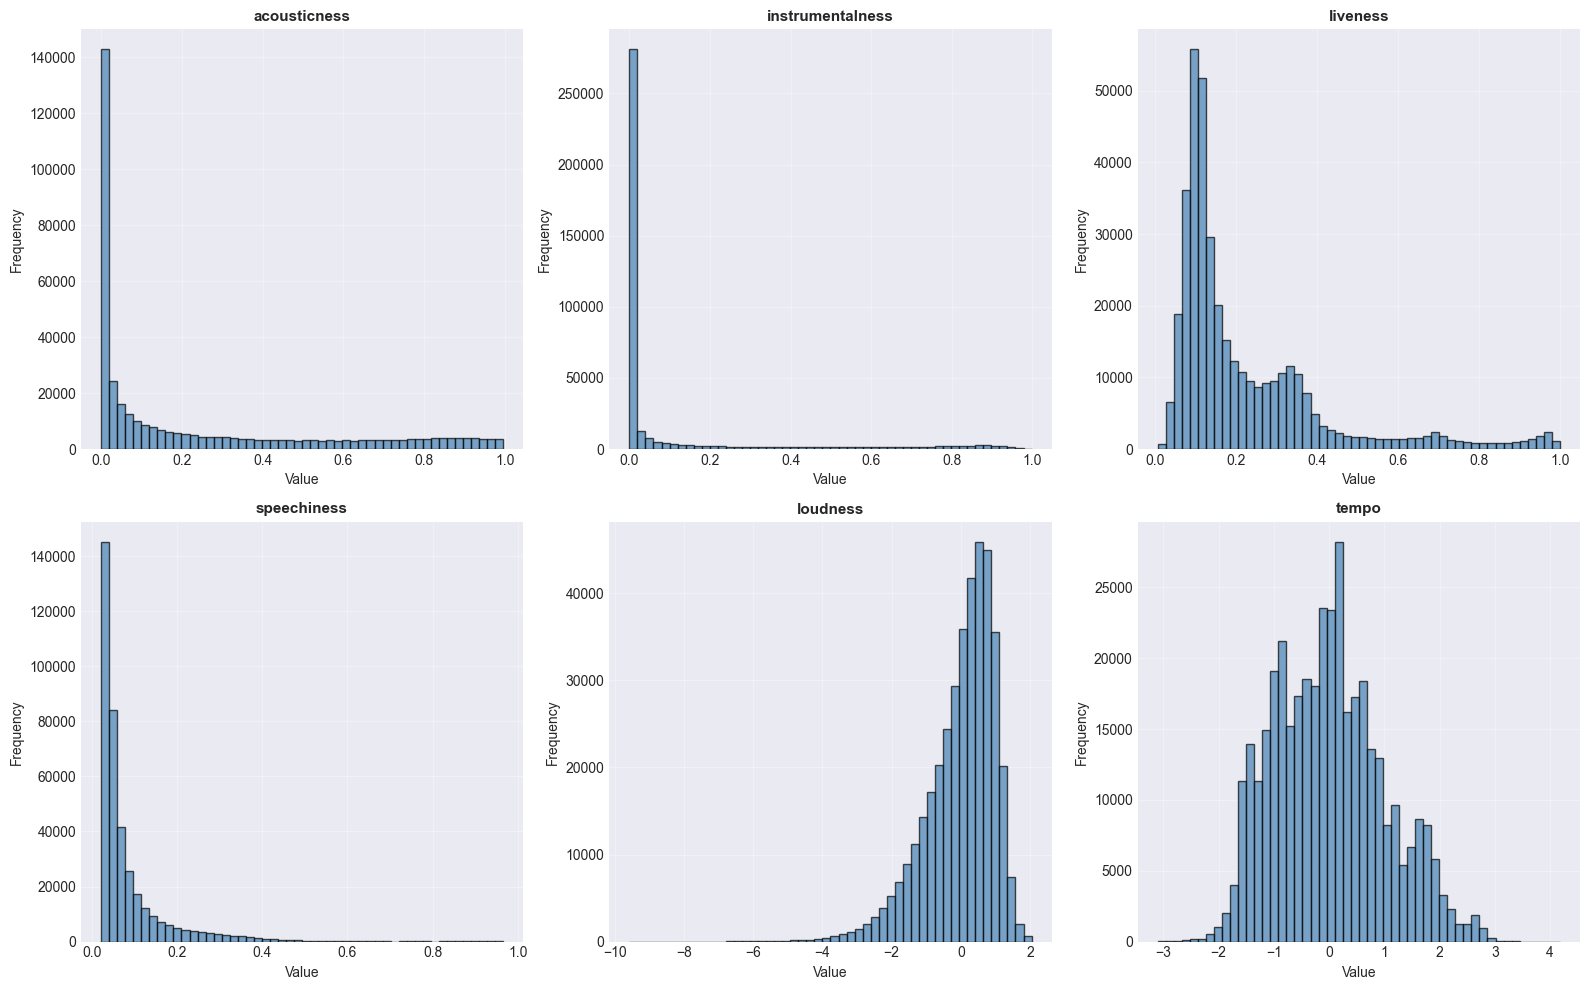

✓ Saved to audio_distributions.png

TEXT_STATS - Training Set Statistics
Features: 5
Mean range: [-0.0000, 0.0000]
Std range:  [1.0000, 1.0000]

First 5 features:


,feature,mean,std,min,max,median
0,word_count,1.306931e-15,1.0,-6.895914,5.351480,0.019757
1,unique_word_count,4.981168e-16,1.0,-6.860724,5.687350,0.035550
2,unique_ratio,-1.341649e-16,1.0,-2.826804,3.772955,-0.077801
3,avg_word_length,3.365892e-16,1.0,-7.091036,41.978096,-0.115377
4,char_count,6.531714e-17,1.0,-6.461694,5.430702,0.020431


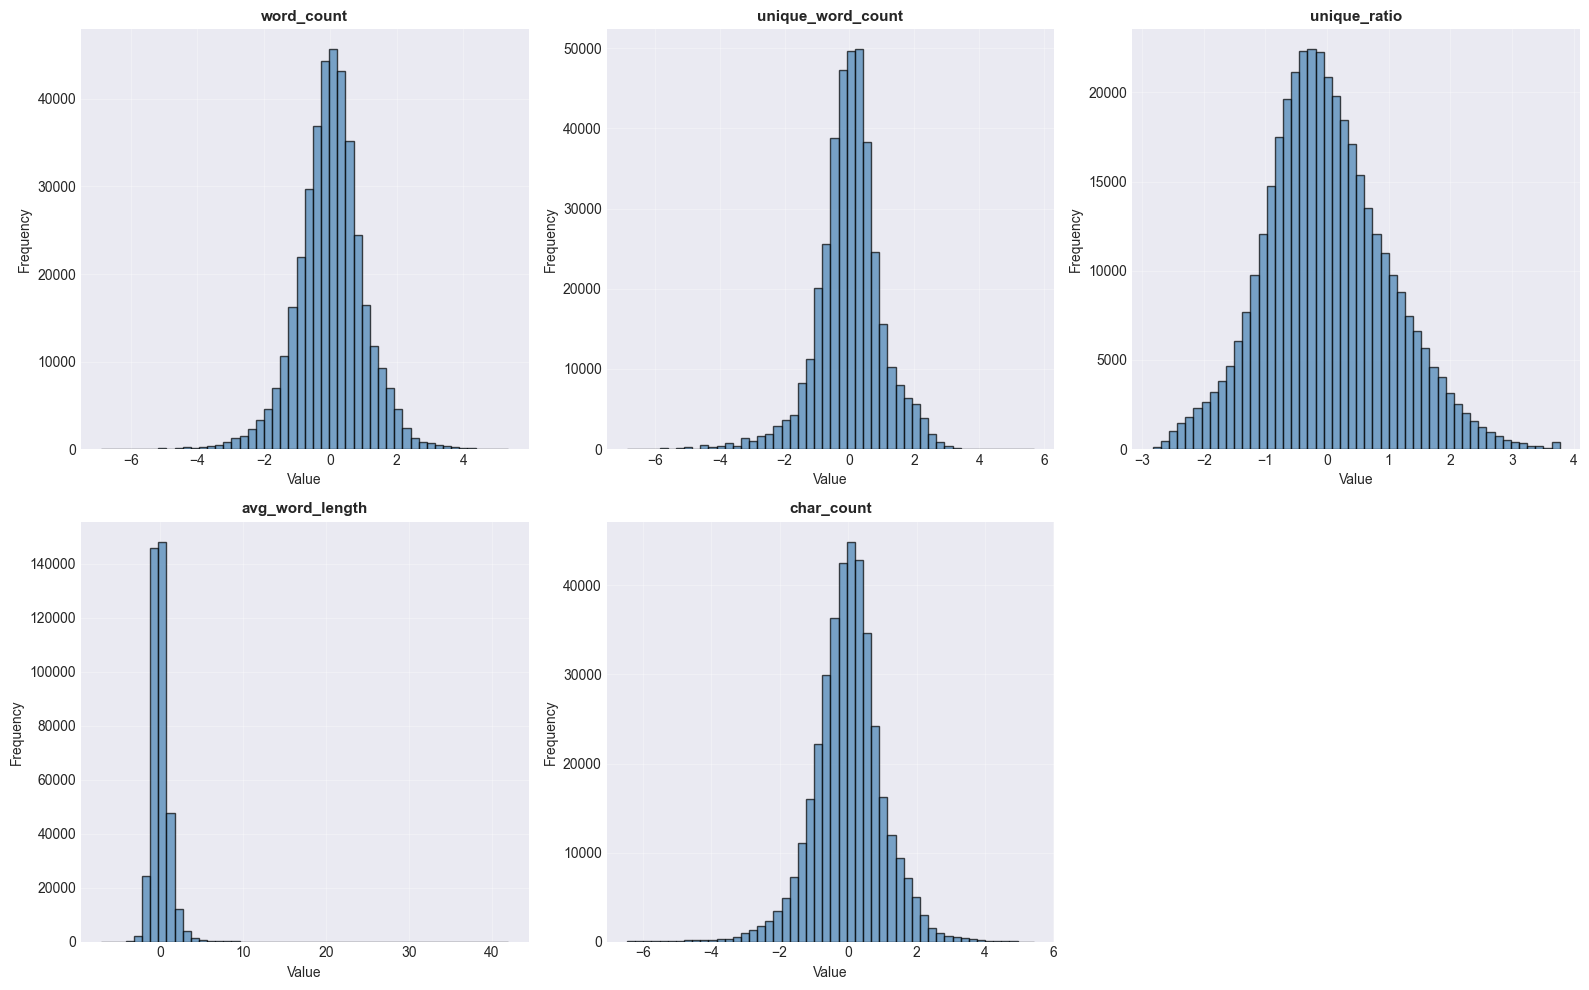

✓ Saved to text_stats_distributions.png

SENTIMENT - Training Set Statistics
Features: 2
Mean range: [0.0000, 0.0000]
Std range:  [1.0000, 1.0000]

First 2 features:


,feature,mean,std,min,max,median
0,sentiment_polarity,4.472165e-17,1.0,-5.617819,4.744828,-0.047896
1,sentiment_subjectivity,1.615275e-16,1.0,-3.320546,3.322655,0.030272


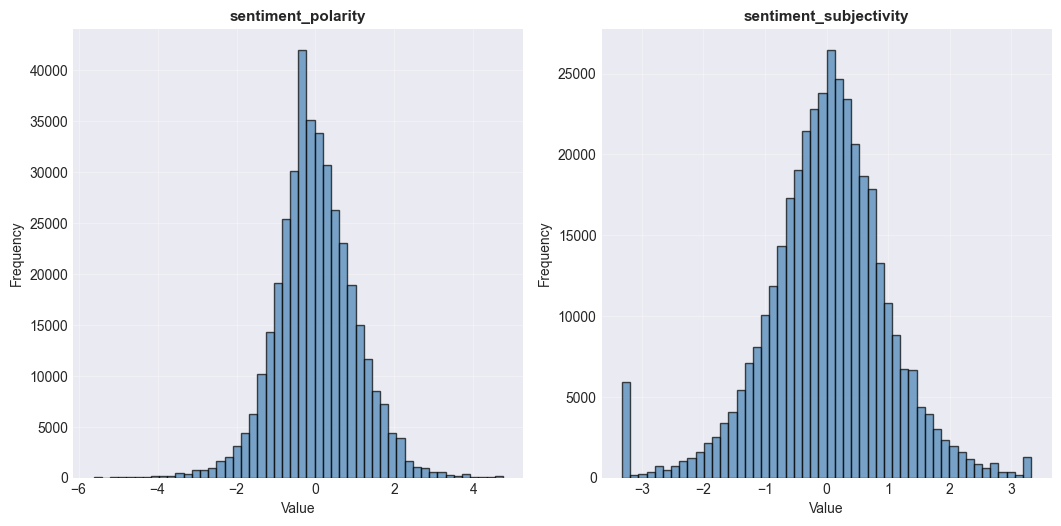

✓ Saved to sentiment_distributions.png


In [ ]:
# Define feature names mapping
feature_names_map = {
    'audio': AUDIO_FEATURE_NAMES,
    'text_stats': TEXT_STAT_NAMES,
    'sentiment': SENTIMENT_NAMES,
    'embeddings': [f'emb_{i}' for i in range(384)]  # 384-d embeddings
}

for feat_name, feat_dict in features.items():
    print(f"\n{'='*80}")
    print(f"{feat_name.upper()} - Training Set Statistics")
    print('='*80)
    
    X = feat_dict['train']
    n_features = X.shape[1]
    
    # Get feature names
    feature_names = feature_names_map.get(feat_name, [f'feature_{i}' for i in range(n_features)])
    
    # Summary statistics per feature
    stats = pd.DataFrame({
        'feature': feature_names[:n_features],
        'mean': X.mean(axis=0),
        'std': X.std(axis=0),
        'min': X.min(axis=0),
        'max': X.max(axis=0),
        'median': np.median(X, axis=0),
    })
    
    print(f"Features: {n_features}")
    print(f"Mean range: [{stats['mean'].min():.4f}, {stats['mean'].max():.4f}]")
    print(f"Std range:  [{stats['std'].min():.4f}, {stats['std'].max():.4f}]")
    
    # Display first 10 features statistics
    if n_features <= 30:
        print(f"\nFirst {min(10, n_features)} features:")
        print(stats.head(10).to_string(index=False))
    
    # Plot distribution of first few features (if not too many)
    if n_features <= 50:
        n_plots = min(6, n_features)
        fig, axes = plt.subplots(2, 3, figsize=(18, 11))
        axes = axes.flatten()
        
        for i in range(n_plots):
            ax = axes[i]
            ax.hist(X[:, i], bins=50, alpha=0.75, edgecolor='black', 
                   color='steelblue', linewidth=1.2)
            feature_label = feature_names[i] if i < len(feature_names) else f'Feature {i}'
            ax.set_title(f'{feature_label}', fontsize=12, fontweight='bold', pad=8)
            ax.set_xlabel('Value', fontsize=11, fontweight='bold')
            ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        
        # Hide unused subplots
        for i in range(n_plots, 6):
            axes[i].set_visible(False)
        
        fig.suptitle(f'{feat_name.upper()} - Feature Distributions', 
                    fontsize=16, fontweight='bold', y=0.995)
        
        plt.tight_layout()
        plt.savefig(output_dir / f'{feat_name}_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved to {feat_name}_distributions.png")

## 7. Target Distributions

Compare train/val/test distributions for all target variables.

VALENCE:
  Train: mean=0.4634, std=0.2492, range=[0.0000, 0.9960]
  Val:   mean=0.4686, std=0.2488, range=[0.0000, 0.9980]
  Test:  mean=0.4661, std=0.2489, range=[0.0000, 0.9940]

ENERGY:
  Train: mean=0.6703, std=0.2467, range=[0.0000, 1.0000]
  Val:   mean=0.6703, std=0.2448, range=[0.0000, 1.0000]
  Test:  mean=0.6768, std=0.2415, range=[0.0002, 1.0000]

DANCEABILITY:
  Train: mean=0.5261, std=0.1730, range=[0.0455, 0.9880]
  Val:   mean=0.5290, std=0.1711, range=[0.0548, 0.9850]
  Test:  mean=0.5306, std=0.1718, range=[0.0578, 0.9870]

POPULARITY:
  Train: mean=2.1233, std=1.4793, range=[0.0000, 4.5218]
  Val:   mean=2.0848, std=1.4898, range=[0.0000, 4.5218]
  Test:  mean=2.1221, std=1.4659, range=[0.0000, 4.4886]

DANCEABILITY:
  Train: mean=0.5261, std=0.1730, range=[0.0455, 0.9880]
  Val:   mean=0.5290, std=0.1711, range=[0.0548, 0.9850]
  Test:  mean=0.5306, std=0.1718, range=[0.0578, 0.9870]

POPULARITY:
  Train: mean=2.1233, std=1.4793, range=[0.0000, 4.5218]
  Val:   mean=

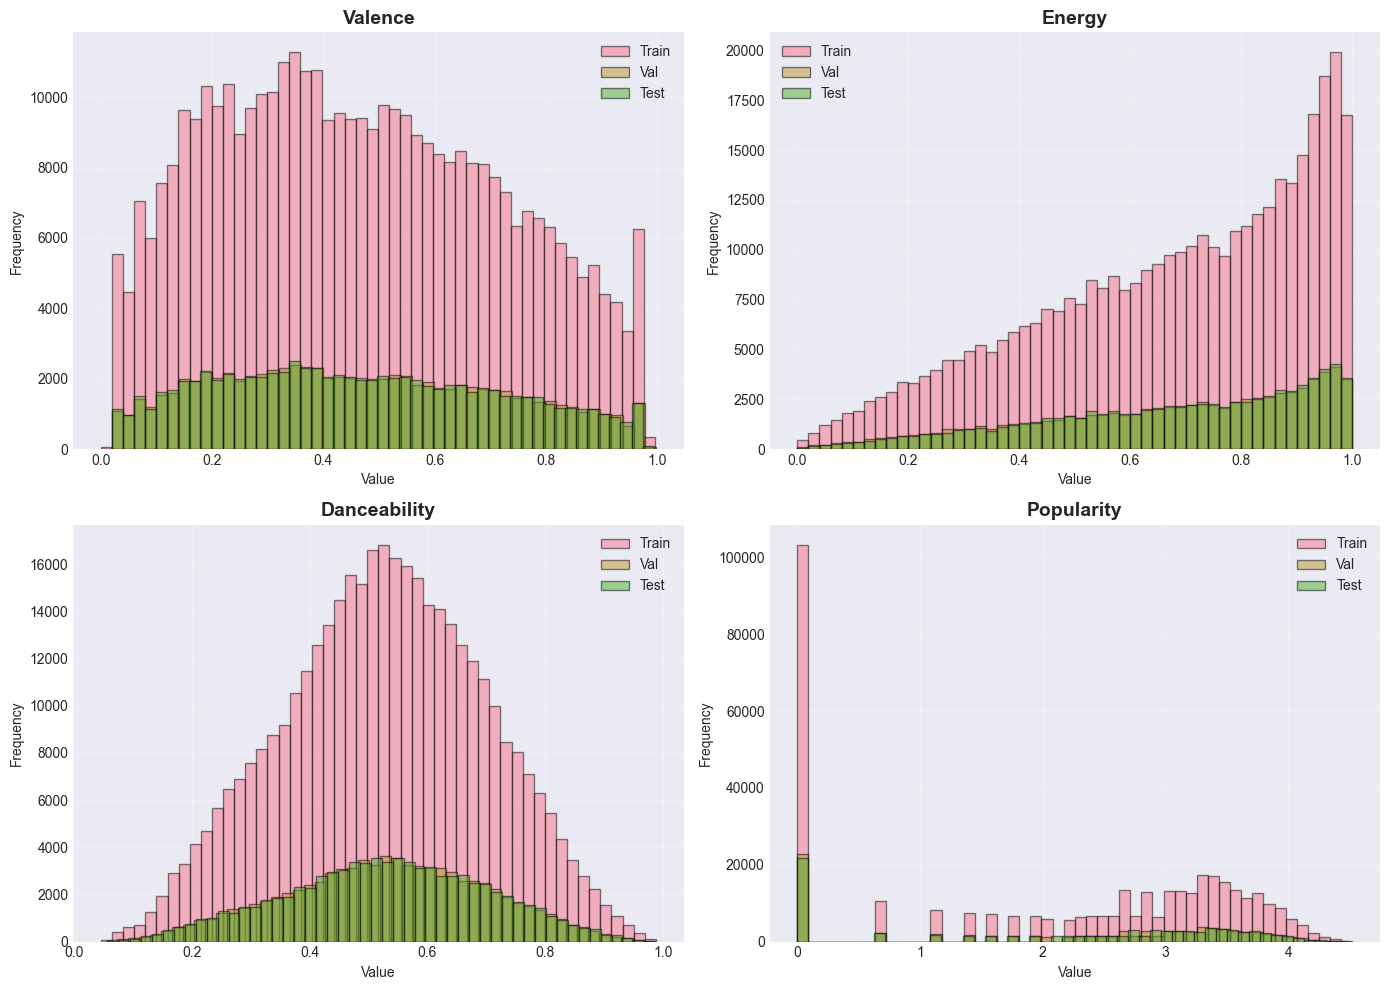

✓ Saved to target_distributions.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Target Variables: Train/Validation/Test Distribution Comparison', 
             fontsize=18, fontweight='bold', y=0.995)

colors = {'train': '#3498db', 'val': '#e74c3c', 'test': '#2ecc71'}

for idx, (target_name, target_dict) in enumerate(targets.items()):
    y_train = target_dict['train']
    y_val = target_dict['val']
    y_test = target_dict['test']
    
    ax = axes[idx // 2, idx % 2]
    
    # Overlapping histograms
    ax.hist(y_train, bins=50, alpha=0.6, label='Train', edgecolor='black', 
            color=colors['train'], linewidth=1.2)
    ax.hist(y_val, bins=50, alpha=0.6, label='Validation', edgecolor='black', 
            color=colors['val'], linewidth=1.2)
    ax.hist(y_test, bins=50, alpha=0.6, label='Test', edgecolor='black', 
            color=colors['test'], linewidth=1.2)
    
    ax.set_title(f'{target_name.capitalize()}', fontsize=15, fontweight='bold', pad=12)
    ax.set_xlabel('Value', fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Print statistics
    print(f"\n{target_name.upper()}:")
    print(f"  Train: μ={y_train.mean():.4f}, σ={y_train.std():.4f}, "
          f"range=[{y_train.min():.4f}, {y_train.max():.4f}]")
    print(f"  Val:   μ={y_val.mean():.4f}, σ={y_val.std():.4f}, "
          f"range=[{y_val.min():.4f}, {y_val.max():.4f}]")
    print(f"  Test:  μ={y_test.mean():.4f}, σ={y_test.std():.4f}, "
          f"range=[{y_test.min():.4f}, {y_test.max():.4f}]")

plt.tight_layout()
plt.savefig(output_dir / 'target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved to target_distributions.png")

## 8. Scalers and Transformers Inspection

Examine saved scaler/transformer objects and their properties.

In [ ]:
scaler_files = {
    'audio_scaler': 'audio_scaler.pkl',
    'text_stats_scaler': 'text_stats_scaler.pkl',
    'sentiment_scaler': 'sentiment_scaler.pkl',
    'audio_power_transformer': 'audio_power_transformer.pkl',
}

print("Scalers and Transformers")
print("=" * 80)

for scaler_name, filename in scaler_files.items():
    filepath = features_dir / filename
    if filepath.exists():
        scaler = joblib.load(filepath)
        print(f"\n{scaler_name}:")
        print(f"  Type: {type(scaler).__name__}")
        
        if hasattr(scaler, 'mean_'):
            print(f"  Mean (first 5): {scaler.mean_[:5]}")
        if hasattr(scaler, 'scale_'):
            print(f"  Scale (first 5): {scaler.scale_[:5]}")
        if hasattr(scaler, 'var_'):
            print(f"  Variance (first 5): {scaler.var_[:5]}")
        if hasattr(scaler, 'n_features_in_'):
            print(f"  N Features: {scaler.n_features_in_}")
    else:
        print(f"\n{scaler_name}: Not found")

Scalers and Transformers

audio_scaler:
  Type: StandardScaler
  Mean (first 5): [-7.89790721e+00  1.22857382e+02  2.38016392e+05  2.00703614e+03]
  Scale (first 5): [3.86181088e+00 2.94658082e+01 9.65659522e+04 1.36335031e+01]
  Variance (first 5): [1.49135833e+01 8.68233854e+02 9.32498312e+09 1.85872407e+02]
  N Features: 4

text_stats_scaler:
  Type: StandardScaler
  Mean (first 5): [5.39038143 4.49117927 0.43337099 4.0406784  7.03142686]
  Scale (first 5): [0.62236404 0.55359055 0.15018176 0.40019256 0.61700608]
  Variance (first 5): [0.387337   0.3064625  0.02255456 0.16015409 0.3806965 ]
  N Features: 5

sentiment_scaler:
  Type: StandardScaler
  Mean (first 5): [0.08424394 0.49984132]
  Scale (first 5): [0.19300088 0.15052985]
  Variance (first 5): [0.03724934 0.02265924]
  N Features: 2

audio_power_transformer:
  Type: PowerTransformer
  N Features: 3


## 9. Correlation Analysis

Compute correlation matrices and identify highly correlated feature pairs.


AUDIO - Correlation Analysis


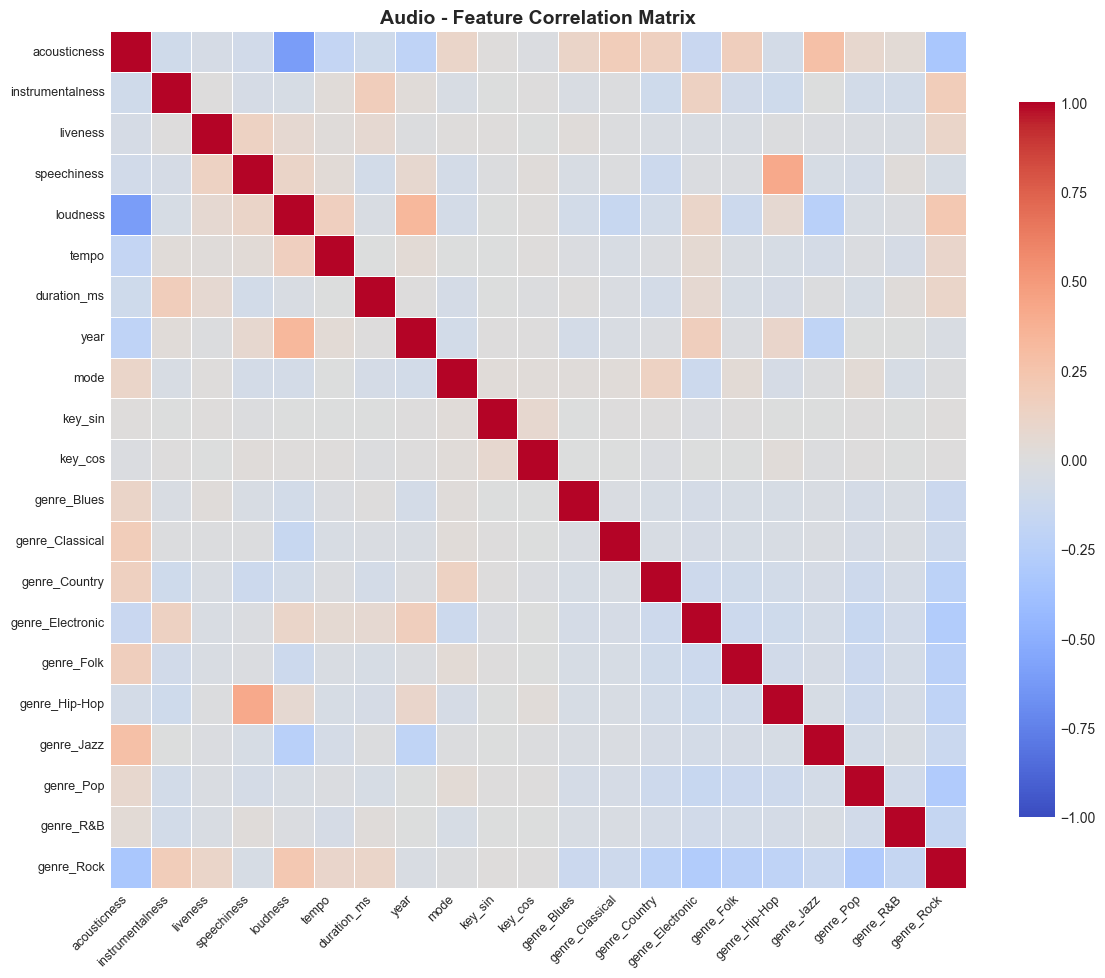

✓ Saved to audio_correlation.png

✓ No highly correlated pairs found (|r| > 0.8)

TEXT_STATS - Correlation Analysis


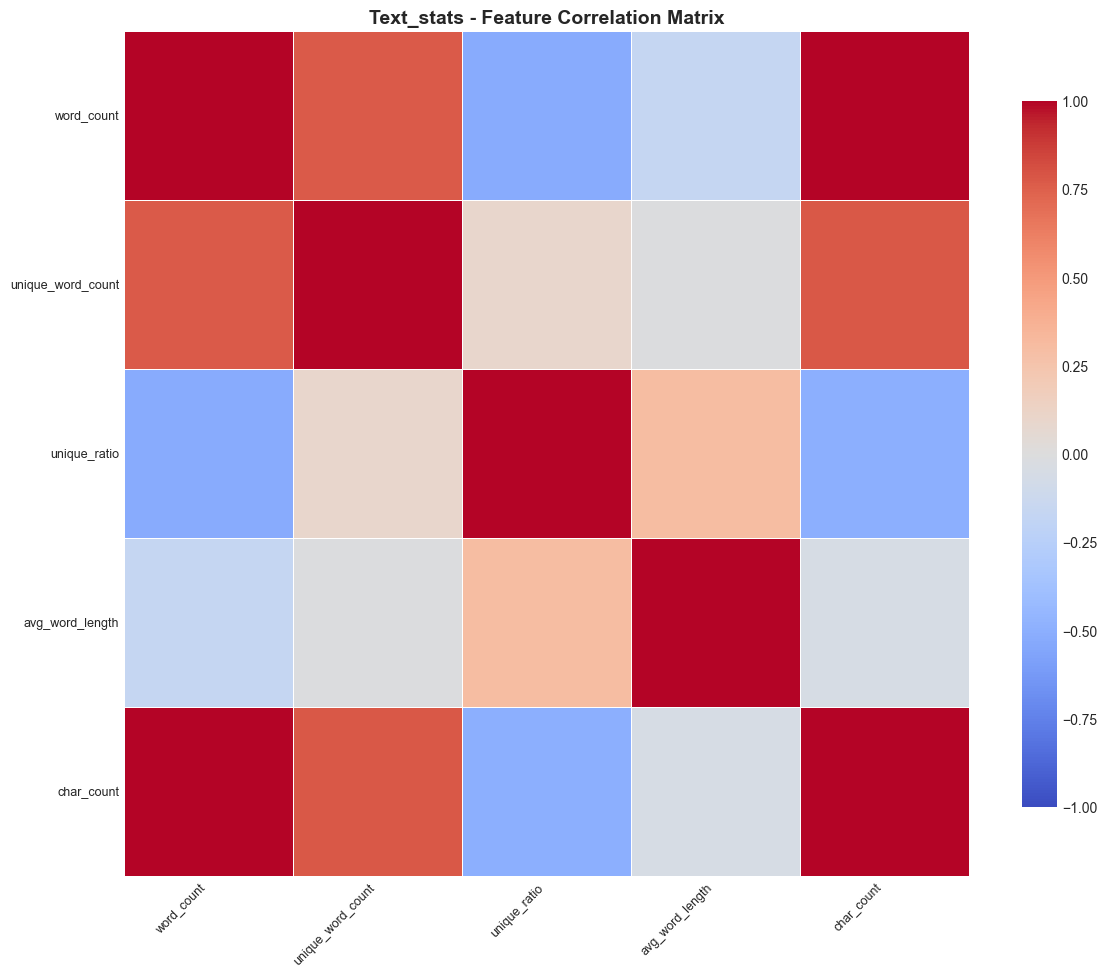

✓ Saved to text_stats_correlation.png

⚠️  Found 1 highly correlated pairs (|r| > 0.8):
    word_count ↔ char_count: r=0.993

SENTIMENT - Correlation Analysis


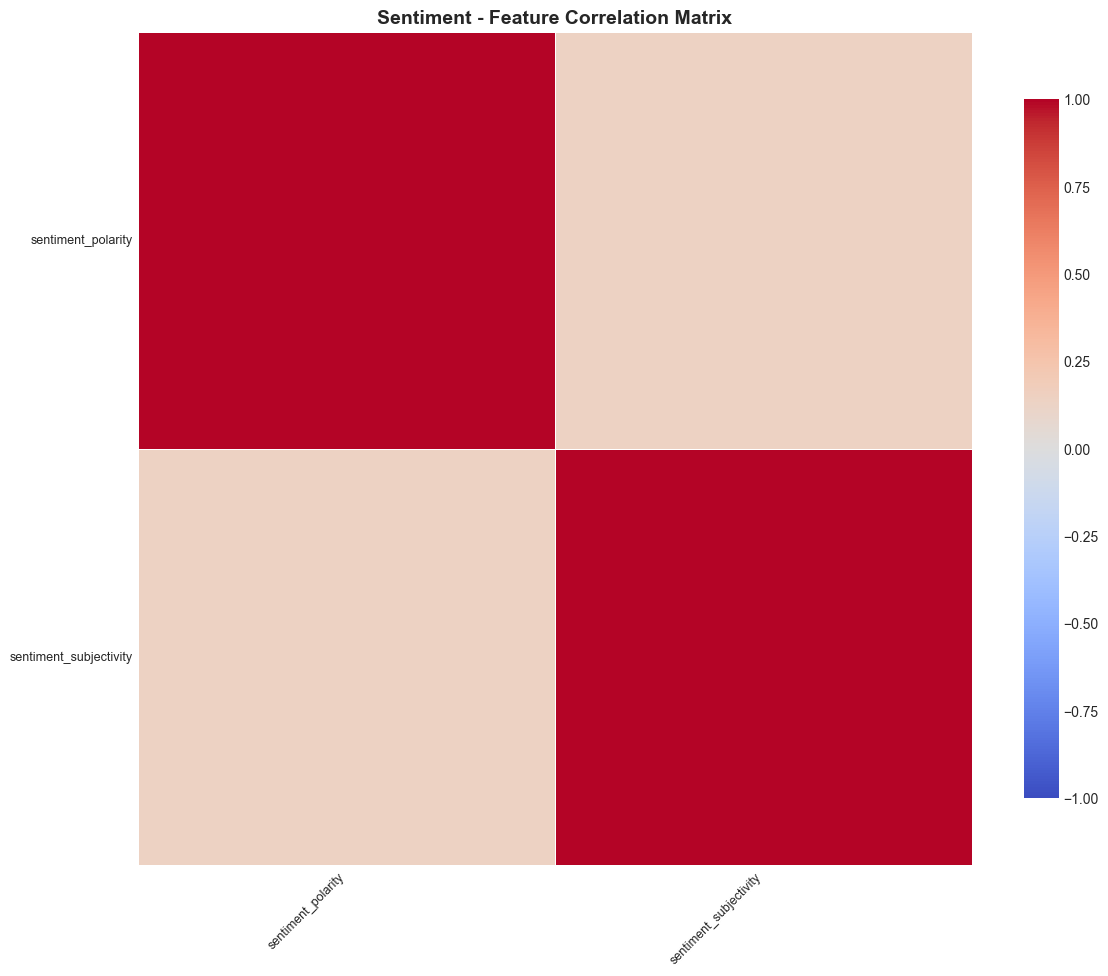

✓ Saved to sentiment_correlation.png

✓ No highly correlated pairs found (|r| > 0.8)


In [ ]:
# Only analyze features with manageable dimensions
for feat_name, feat_dict in features.items():
    X = feat_dict['train']
    n_features = X.shape[1]
    
    # Get feature names
    feature_names = feature_names_map.get(feat_name, [f'feature_{i}' for i in range(n_features)])
    
    if n_features <= 30:  # Only for manageable sizes
        print(f"\n{'='*80}")
        print(f"{feat_name.upper()} - Correlation Analysis")
        print('='*80)
        
        # Compute correlation
        corr = np.corrcoef(X.T)
        
        # Plot heatmap
        fig, ax = plt.subplots(figsize=(14, 12))
        
        # Use feature names for labels
        sns.heatmap(corr, cmap='RdBu_r', center=0, 
                    square=True, linewidths=1.5, linecolor='white',
                    cbar_kws={"shrink": 0.85, "label": "Pearson Correlation (r)"},
                    annot=True, fmt='.2f', annot_kws={"fontsize": 8, "weight": "bold"},
                    vmin=-1, vmax=1,
                    xticklabels=feature_names[:n_features],
                    yticklabels=feature_names[:n_features], ax=ax)
        
        ax.set_title(f'{feat_name.upper()} - Feature Correlation Matrix', 
                     fontsize=16, fontweight='bold', pad=15)
        
        # Rotate labels for readability
        plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold')
        plt.yticks(rotation=0, fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(output_dir / f'{feat_name}_correlation.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved to {feat_name}_correlation.png")
        
        # Find highly correlated pairs
        high_corr = []
        for i in range(n_features):
            for j in range(i+1, n_features):
                if abs(corr[i, j]) > 0.8:
                    high_corr.append((i, j, corr[i, j]))
        
        if high_corr:
            print(f"\n⚠️  Found {len(high_corr)} highly correlated pairs (|r| > 0.8):")
            for i, j, r in high_corr[:10]:  # Show first 10
                feat_i = feature_names[i] if i < len(feature_names) else f'Feature {i}'
                feat_j = feature_names[j] if j < len(feature_names) else f'Feature {j}'
                print(f"    {feat_i:20s} ↔ {feat_j:20s}: r = {r:.3f}")
        else:
            print("\n✓ No highly correlated pairs found (|r| > 0.8)")
    else:
        print(f"\n{feat_name.upper()}: {n_features} features (too many for detailed correlation heatmap)")
        
        # For embeddings, show correlation structure summary
        if feat_name == 'embeddings':
            corr = np.corrcoef(X.T)
            high_corr_count = (np.abs(corr) > 0.8).sum() - n_features  # Exclude diagonal
            high_corr_count = high_corr_count // 2  # Each pair counted twice
            avg_corr = np.mean(np.abs(corr[np.triu_indices_from(corr, k=1)]))
            print(f"  High correlation pairs (|r| > 0.8): {high_corr_count}")
            print(f"  Average absolute correlation: {avg_corr:.3f}")

## 9b. Feature Importance by Variance

Analyze feature importance based on variance (useful for dimensionality assessment).

## 10. Summary Report

Comprehensive summary of all analyzed features and files.


AUDIO - Variance Analysis
Variance range: [0.008549, 1.000000]
Mean variance: 0.296748

Top 10 features by variance:


,feature,variance
7,year,1.000000
5,tempo,1.000000
6,duration_ms,1.000000
4,loudness,1.000000
10,key_cos,0.530998
9,key_sin,0.466047
20,genre_Rock,0.229427
8,mode,0.221703
18,genre_Pop,0.115436
14,genre_Electronic,0.109961


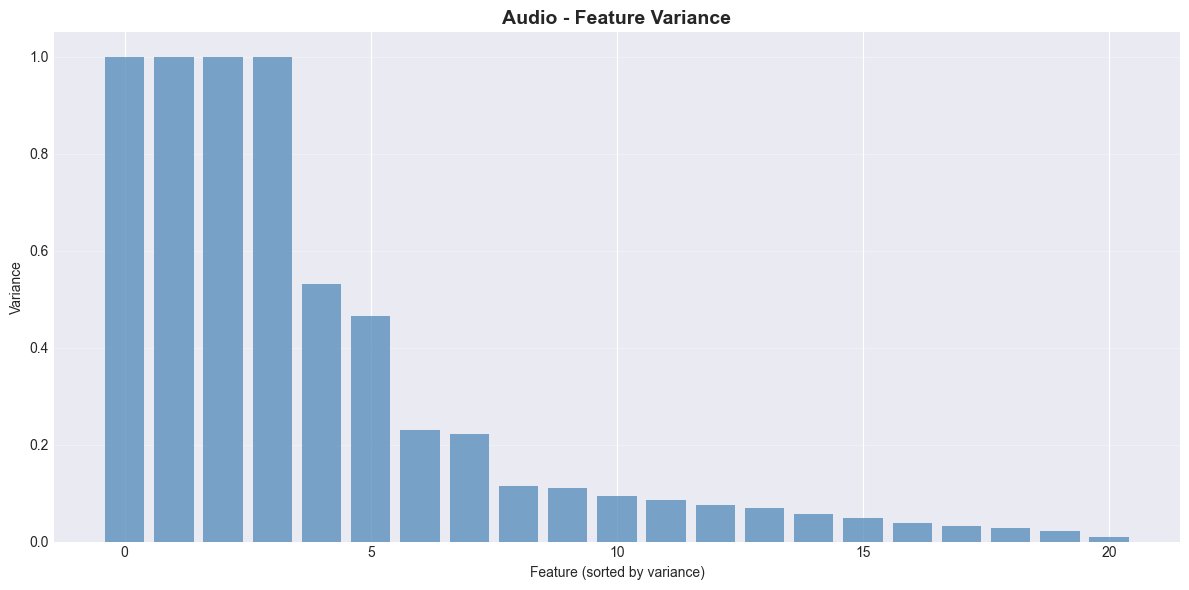

✓ Saved to audio_variance.png

TEXT_STATS - Variance Analysis
Variance range: [1.000000, 1.000000]
Mean variance: 1.000000

Top 10 features by variance:


,feature,variance
3,avg_word_length,1.0
1,unique_word_count,1.0
0,word_count,1.0
2,unique_ratio,1.0
4,char_count,1.0


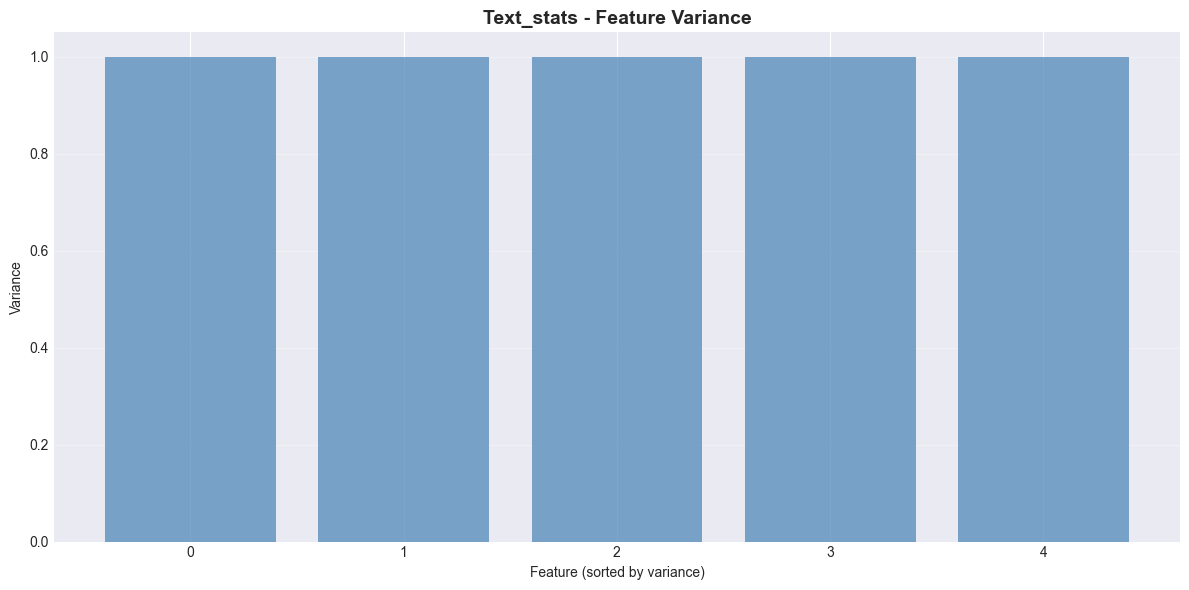

✓ Saved to text_stats_variance.png

SENTIMENT - Variance Analysis
Variance range: [1.000000, 1.000000]
Mean variance: 1.000000

Top 10 features by variance:


,feature,variance
0,sentiment_polarity,1.0
1,sentiment_subjectivity,1.0


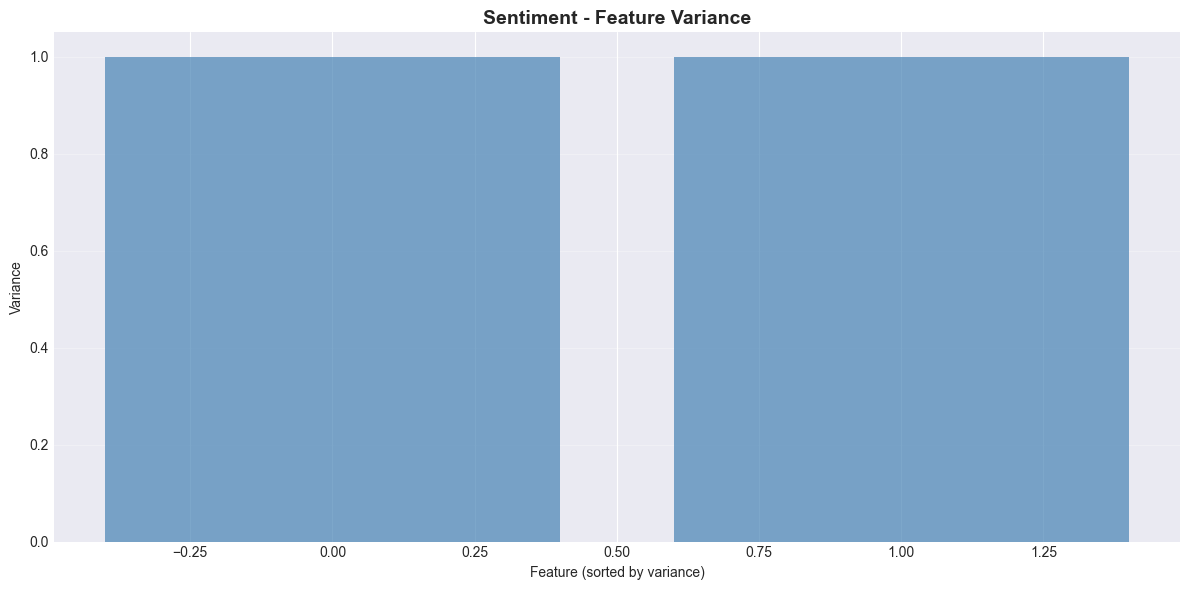

✓ Saved to sentiment_variance.png


In [ ]:
# Analyze variance for each feature type
for feat_name, feat_dict in features.items():
    X = feat_dict['train']
    n_features = X.shape[1]
    
    # Get feature names
    feature_names = feature_names_map.get(feat_name, [f'feature_{i}' for i in range(n_features)])
    
    print(f"\n{'='*80}")
    print(f"{feat_name.upper()} - Variance Analysis")
    print('='*80)
    
    # Compute variance
    variances = X.var(axis=0)
    
    # Create variance dataframe
    var_df = pd.DataFrame({
        'feature': feature_names[:n_features],
        'variance': variances,
    }).sort_values('variance', ascending=False)
    
    print(f"Variance range: [{variances.min():.6f}, {variances.max():.6f}]")
    print(f"Mean variance: {variances.mean():.6f}")
    
    # Show top variance features
    if n_features <= 30:
        print(f"\nTop 10 features by variance:")
        print(var_df.head(10).to_string(index=False))
        
        # Plot variance - Academic style
        fig, ax = plt.subplots(figsize=(14, 7))
        bars = ax.bar(range(len(variances)), var_df['variance'].values, 
                     color='steelblue', alpha=0.75, edgecolor='black', linewidth=1.2)
        
        ax.set_xlabel('Feature (ranked by variance)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Variance', fontsize=13, fontweight='bold')
        ax.set_title(f'{feat_name.upper()} - Feature Variance Ranking', 
                    fontsize=16, fontweight='bold', pad=15)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Highlight top 3
        for i in range(min(3, len(bars))):
            bars[i].set_color('#e74c3c')
            bars[i].set_alpha(0.9)
        
        plt.tight_layout()
        plt.savefig(output_dir / f'{feat_name}_variance.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved to {feat_name}_variance.png")
    else:
        # For high-dimensional features (embeddings)
        low_var_count = (variances < 0.01).sum()
        print(f"Low variance features (var < 0.01): {low_var_count} ({low_var_count/n_features*100:.1f}%)")

In [ ]:
print("="*80)
print("FEATURE FILES EDA - SUMMARY REPORT")
print("="*80)

total_features = sum(feat_dict['train'].shape[1] for feat_dict in features.values())
total_samples_train = list(features.values())[0]['train'].shape[0] if features else 0

print(f"\n📊 FEATURE INVENTORY")
print(f"{'='*80}")
print(f"  Total features: {total_features}")
for feat_name, feat_dict in features.items():
    n_feat = feat_dict['train'].shape[1]
    pct = (n_feat / total_features * 100) if total_features > 0 else 0
    print(f"  • {feat_name.capitalize():15s}: {n_feat:3d} features ({pct:5.1f}%)")

print(f"\n📦 DATASET SPLITS")
print(f"{'='*80}")
if features:
    train_size = list(features.values())[0]['train'].shape[0]
    val_size = list(features.values())[0]['val'].shape[0]
    test_size = list(features.values())[0]['test'].shape[0]
    total_size = train_size + val_size + test_size
    
    print(f"  Training:   {train_size:7,} samples ({train_size/total_size*100:5.1f}%)")
    print(f"  Validation: {val_size:7,} samples ({val_size/total_size*100:5.1f}%)")
    print(f"  Test:       {test_size:7,} samples ({test_size/total_size*100:5.1f}%)")
    print(f"  {'─'*80}")
    print(f"  Total:      {total_size:7,} samples (100.0%)")

print(f"\n📁 FILES PROCESSED")
print(f"{'='*80}")
print(f"  NumPy arrays (.npy): {len(npy_files)}")
print(f"  Pickle files (.pkl): {len(pkl_files)}")

print(f"\n📈 VISUALIZATIONS GENERATED")
print(f"{'='*80}")
viz_files = sorted(output_dir.glob("*.png"))
print(f"  Total: {len(viz_files)} publication-quality figures")
for vf in viz_files:
    print(f"  • {vf.name}")

print(f"\n✓ All visualizations saved to: {output_dir.absolute()}")
print(f"✓ Resolution: 300 DPI (publication quality)")
print("="*80)

FEATURE FILES EDA - SUMMARY REPORT

📊 FEATURES AVAILABLE
  Total features: 28
  - Audio: 21 features
  - Text_stats: 5 features
  - Sentiment: 2 features

📦 DATASET SIZES
  Training samples:   386,399
  Validation samples: 82,187
  Test samples:       82,274

📁 FILES PROCESSED
  NumPy arrays (.npy): 21
  Pickle files (.pkl): 6

📈 VISUALIZATIONS SAVED
  Total: 10 files
  - audio_correlation.png
  - audio_distributions.png
  - audio_variance.png
  - sentiment_correlation.png
  - sentiment_distributions.png
  - sentiment_variance.png
  - target_distributions.png
  - text_stats_correlation.png
  - text_stats_distributions.png
  - text_stats_variance.png

✓ All visualizations saved to: /home/esstee/documents/bitirme/notebooks/../results/figures/feature_eda
